In [10]:
import ast, io

import pandas as pd
import matplotlib as mpl
mpl.use('Agg')
import matplotlib.pyplot as plt

from IPython.display import display, Image
from src.theory.error_bar import *

In [11]:
dim = 5
with open(f'../data/simulation/dim_{dim}/ov0.75_noise0.0.csv', 'r', encoding='utf-8-sig') as file:
    data = pd.read_csv(file)
print(data.head())

      timestamp optimizer  lambda_val  fixed rate  \
0  260403125622    COBYLA        60.0      0.0000   
1  260403125622    COBYLA        60.0      0.1875   
2  260403125622    COBYLA        60.0      0.3750   
3  260403125622    COBYLA        60.0      0.5625   
4  260403125622    COBYLA        60.0      0.7500   

                                             history  \
0  [[4.6121381887940105, 6.182934188794011, 6.182...   
1  [[3.252672864233273, 4.8234688642332735, 3.252...   
2  [[2.1835984683702825, 3.7543944683702826, 2.18...   
3  [[6.161701528748072, 7.7324975287480715, 6.161...   
4  [[4.172556232677567, 5.743352232677568, 4.1725...   

                                            raw_data  
0  [[0.1635111324724599, 0.029751649127517734, 0....  
1  [[0.1496050370546716, 0.02089742069264111, 0.0...  
2  [[0.020686217903062017, 0.003944691274138763, ...  
3  [[0.10568195298539246, 0.01081094376111112, 0....  
4  [[0.0251772806150593, 0.0007337698700423689, 0...  


In [12]:
columns = ['timestamp', 'optimizer', 'lambda_val', 'fixed rate', 'raw_data']
df = data[columns].copy()
print(df)

        timestamp optimizer  lambda_val  fixed rate  \
0    260403125622    COBYLA        60.0      0.0000   
1    260403125622    COBYLA        60.0      0.1875   
2    260403125622    COBYLA        60.0      0.3750   
3    260403125622    COBYLA        60.0      0.5625   
4    260403125622    COBYLA        60.0      0.7500   
..            ...       ...         ...         ...   
495  260403125709    COBYLA        60.0      0.0000   
496  260403125709    COBYLA        60.0      0.1875   
497  260403125709    COBYLA        60.0      0.3750   
498  260403125709    COBYLA        60.0      0.5625   
499  260403125709    COBYLA        60.0      0.7500   

                                              raw_data  
0    [[0.1635111324724599, 0.029751649127517734, 0....  
1    [[0.1496050370546716, 0.02089742069264111, 0.0...  
2    [[0.020686217903062017, 0.003944691274138763, ...  
3    [[0.10568195298539246, 0.01081094376111112, 0....  
4    [[0.0251772806150593, 0.0007337698700423689, 0...

In [13]:
df['raw_data'] = df['raw_data'].apply(ast.literal_eval)
df['raw_data'] = df['raw_data'].apply(lambda m: np.array(m)*1000)
cols = ['success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
df[cols] = df['raw_data'].apply(get_monte_carlo_error)
print(df)

        timestamp optimizer  lambda_val  fixed rate  \
0    260403125622    COBYLA        60.0      0.0000   
1    260403125622    COBYLA        60.0      0.1875   
2    260403125622    COBYLA        60.0      0.3750   
3    260403125622    COBYLA        60.0      0.5625   
4    260403125622    COBYLA        60.0      0.7500   
..            ...       ...         ...         ...   
495  260403125709    COBYLA        60.0      0.0000   
496  260403125709    COBYLA        60.0      0.1875   
497  260403125709    COBYLA        60.0      0.3750   
498  260403125709    COBYLA        60.0      0.5625   
499  260403125709    COBYLA        60.0      0.7500   

                                              raw_data  success rate  \
0    [[163.5111324724599, 29.751649127517734, 20.82...      0.572131   
1    [[149.60503705467158, 20.897420692641113, 20.0...      0.556378   
2    [[20.68621790306202, 3.944691274138763, 45.662...      0.264902   
3    [[105.68195298539246, 10.81094376111112, 3.405

In [14]:
optimizer = df['optimizer'].unique()[0]
columns = ['fixed rate', 'success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
for lambda_val in df['lambda_val'].unique():
    file_name = f"data/[{optimizer}, {dim}dim] lambda={lambda_val}.csv"
    sep_df = df[df['lambda_val'] == lambda_val][columns]
    sep_df.to_csv(file_name, mode='a', index=False, encoding='utf-8-sig')


In [15]:
lambda_val = 60.0
with open(f'data/[COBYLA, {dim}dim] lambda={lambda_val}.csv', 'r', encoding='utf-8-sig') as file:
    processed_data = pd.read_csv(file)

with open(f"../data/theory/dim_{dim}/ov0.75.csv", "r", encoding='utf-8-sig') as file:
    theory_df = pd.read_csv(file)

processed_data = processed_data[processed_data['fixed rate'] != 'fixed rate']
processed_data = processed_data.apply(pd.to_numeric)
processed_data = processed_data.reset_index(drop=True)
theory_df = theory_df.apply(pd.to_numeric)

rms_list = []

for idx, row in processed_data.iterrows():
    fixed_rate_val = row['fixed rate']

    fixed_rate_idx = np.abs(theory_df['fixed rate'] - fixed_rate_val).argmin()

    succ_diff = theory_df.iloc[fixed_rate_idx]['success rate'] - row['success rate']
    error_diff = theory_df.iloc[fixed_rate_idx]['error rate'] - row['error rate']
    fail_diff = theory_df.iloc[fixed_rate_idx]['failure rate'] - row['failure rate']

    rms = np.sqrt((succ_diff**2 + error_diff**2 + fail_diff**2) / 3)
    rms_list.append(rms)

processed_data['rms'] = rms_list


0.03608380849333172


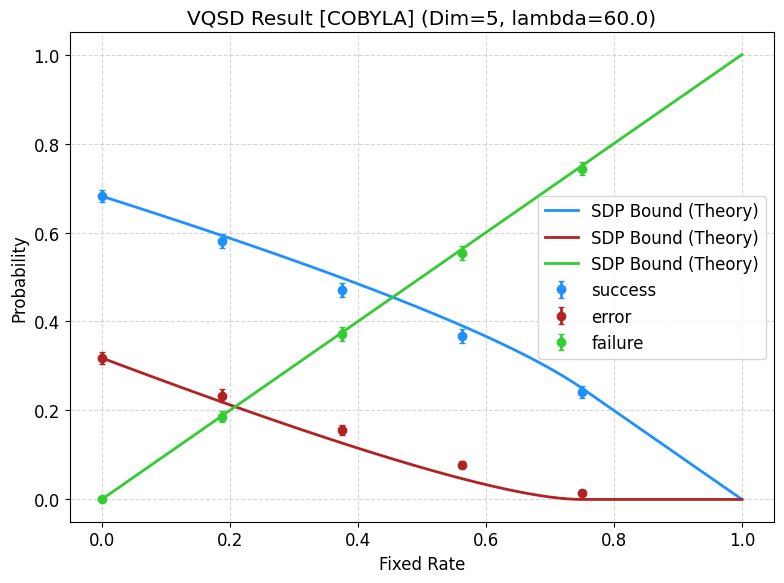

In [16]:
best_idx = processed_data.groupby(['fixed rate'])['rms'].idxmin()
best_processed_data = processed_data.iloc[best_idx]

plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2})
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(theory_df['fixed rate'], theory_df['success rate'], label='SDP Bound (Theory)', color='dodgerblue', linestyle='-')
ax.plot(theory_df['fixed rate'], theory_df['error rate'], label='SDP Bound (Theory)', color='firebrick', linestyle='-')
ax.plot(theory_df['fixed rate'], theory_df['failure rate'], label='SDP Bound (Theory)', color='limegreen', linestyle='-')

color = {
    'success': 'dodgerblue',
    'failure': 'limegreen',
    'error': 'firebrick'
}

x = best_processed_data['fixed rate']
for data_type in ['success', 'error', 'failure']:
    ax.errorbar(x, best_processed_data[f'{data_type} rate'], best_processed_data[f'{data_type} std'], fmt='o', color=color[data_type], capsize=2, label=data_type)
ax.set_xlabel('Fixed Rate')
ax.set_ylabel('Probability')
ax.set_title(f'VQSD Result [COBYLA] (Dim={dim}, lambda={lambda_val})')
ax.legend(loc='center right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

total_rms = 0
for idx, row in best_processed_data.iterrows():
    if idx != 0:
        total_rms += float(row['rms'])**2
print(np.sqrt(total_rms))

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))
plt.close()